# Michelson Repro with the bobcat model

What we want to do here, is use the bobcat model to reproduce the color color graph, specially around the lower temperture brown dwarfs. This model doesn't have all of the variables that you can manipulate, but it will at least give us a successful color-color graph to form a baseline for future explorations

In [25]:
%load_ext autoreload
%autoreload 2

import numpy as np
import helpers.generate_planet_list as helpers
import helpers.generate_galaxy_data as galaxy_helpers
import matplotlib.pyplot as plt
from species import SpeciesInit
from species.data.database import Database
from species.read.read_model import ReadModel
from species.read.read_filter import ReadFilter
from species.phot.syn_phot import SyntheticPhotometry

SpeciesInit()
db = Database()



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
species

Version: 0.10.4
Working folder: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/michelson-repro

Configuration file: /Users/mitchellfoote/Documents/Source/research/dwarfhunt/michelson-repro/species_config.ini
Database file: species_database.hdf5
Data folder: data

Configuration settings:
   - Database: species_database.hdf5
   - Data folder: data
   - Magnitude of Vega: 0.03

Multiprocessing: mpi4py not installed


## Loading the models
If you already have the bobcat model downloaded, you don't need to run this section

In [ ]:
db.add_model('sonora-bobcat', wavel_range=(0.61, 17.0), wavel_sampling=1000.0)

## Generate the planet arrays

We'll use our helper functions to generate the planet arrays based on the params of the model. Because we're only using a single model, we're going to do 300 areas, just to make sure we have enough at the lower edge (which is what we're looking for anyway.)

In [21]:
bobcat_model = ReadModel('sonora-bobcat')
bobcat_planets = helpers.generate_planet_arrays(bobcat_model, radius_range=(0.6, 1.3), distance=10, num_samples=300)

## Build out the mag / color data

Now that we have the data, we can use the helper functions to get the magnitude and color columns needed for the color - color graph. We first get the magnitudes, then the color columns, and then we break everything down to a np array where we can then graph it effectively across the different filters. 

In [22]:
bobcat_planets = helpers.update_planet_flux_and_magnitude(bobcat_model, bobcat_planets, ['JWST/MIRI.F1065C', 'JWST/MIRI.F1140C', 'JWST/MIRI.F1550C'])
bobcat_planets = helpers.add_color_columns(bobcat_planets, ['F1065C', 'F1140C', 'F1550C'])
names, colors = helpers.color_color_matrix(bobcat_planets)

## Get that Galaxy data

Now that we have the planet colors, we can now get the color color data from the galaxies we built in the `michelson-galaxy-graph.ipynb` file. I'm going to move the galaxy specific code over to a new helpers file. 

In [23]:
AGN_00_data = galaxy_helpers.galaxy_color_color_data('./galaxy-data/swire-library/N6090_template_norm.sed')
AGN_05_data = galaxy_helpers.galaxy_color_color_data('./galaxy-data/swire-library/Mrk231_template_norm.sed')
AGN_10_data = galaxy_helpers.galaxy_color_color_data('./galaxy-data/swire-library/QSO1_template_norm.sed')

## Putting it all together. 

Now that we have both the galaxy and bobcat brown dwarfs, we can build out the color color graphs showcased by Michelson (without the correct model or the used Galaxy templates), but it should still showcase some overlap as these templates redshift. It won't be perfect, but should still show the issue. 

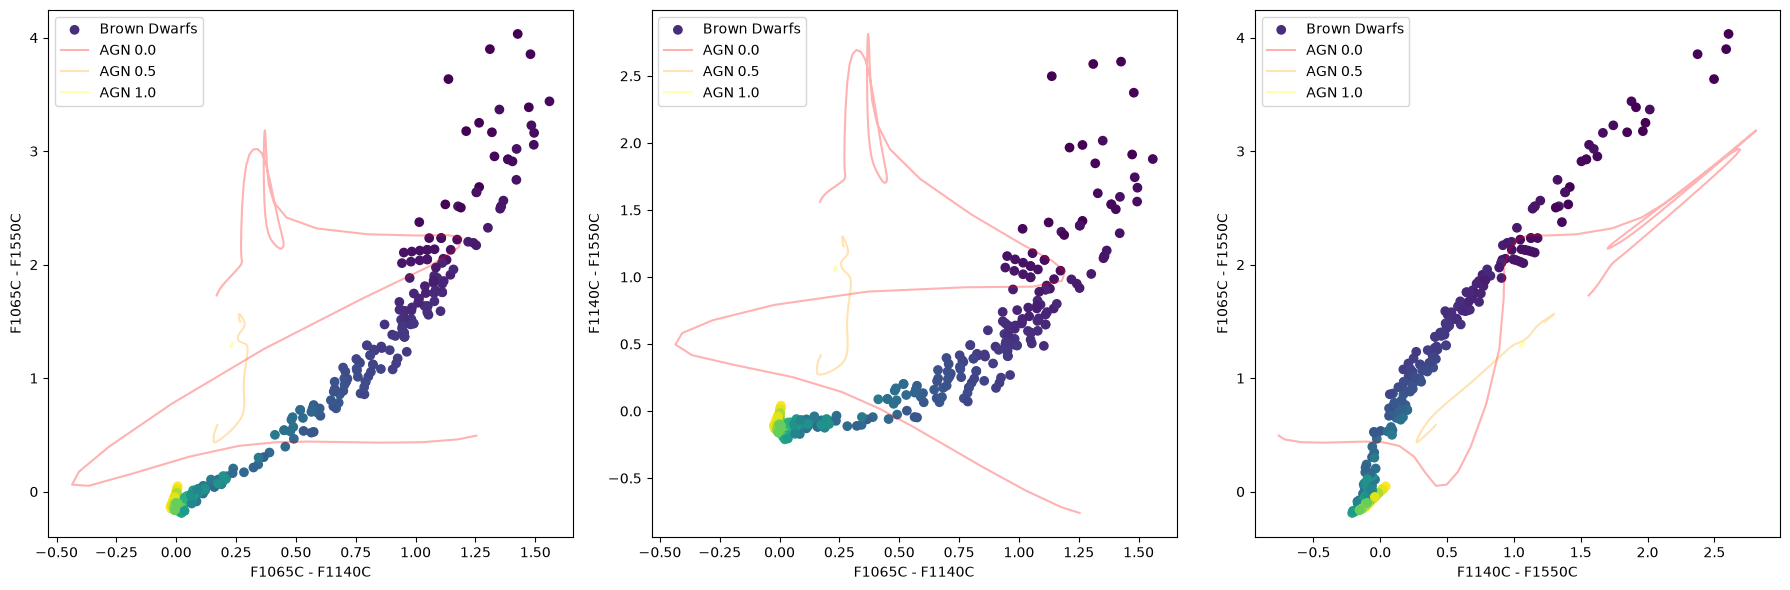

In [26]:
fix, ax = plt.subplots(1,3, figsize=(18,6))

# Color-Color 1 1065 - 1140 (x) vs 1065 - 1550 (y)
# Planets
ax[0].scatter(colors[:, names.index('F1065C - F1140C')], colors[:, names.index('F1065C - F1550C')], c=bobcat_planets["teff"], cmap='viridis', label='Brown Dwarfs')
galaxy_helpers.plot_color_color(AGN_00_data, 'AGN 0.0', ax[0], 'red', 0, 2, 'F1065C - F1140C', 'F1065C - F1550C')
galaxy_helpers.plot_color_color(AGN_05_data, 'AGN 0.5', ax[0], 'orange', 0, 2, 'F1065C - F1140C', 'F1065C - F1550C')
galaxy_helpers.plot_color_color(AGN_10_data, 'AGN 1.0', ax[0], 'yellow', 0, 2, 'F1065C - F1140C', 'F1065C - F1550C')
ax[0].set_xlabel('F1065C - F1140C')
ax[0].set_ylabel('F1065C - F1550C')

# Color-Color 2 F1065 - F1140 (x) vs F1140 - F1550 (y)
ax[1].scatter(colors[:, names.index('F1065C - F1140C')], colors[:, names.index('F1140C - F1550C')], c=bobcat_planets["teff"], cmap='viridis', label='Brown Dwarfs')
galaxy_helpers.plot_color_color(AGN_00_data, 'AGN 0.0', ax[1], 'red', 0, 1, 'F1065C - F1140C', 'F1140C - F1550C')
galaxy_helpers.plot_color_color(AGN_05_data, 'AGN 0.5', ax[1], 'orange', 0, 1, 'F1065C - F1140C', 'F1140C - F1550C')
galaxy_helpers.plot_color_color(AGN_10_data, 'AGN 1.0', ax[1], 'yellow', 0, 1, 'F1065C - F1140C', 'F1140C - F1550C')
ax[1].set_xlabel('F1065C - F1140C')
ax[1].set_ylabel('F1140C - F1550C')

# Color-Color 3 F1140 - F1550 (x) vs F1065 - F1550 (y)
ax[2].scatter(colors[:, names.index('F1140C - F1550C')], colors[:, names.index('F1065C - F1550C')], c=bobcat_planets["teff"], cmap='viridis', label='Brown Dwarfs')
galaxy_helpers.plot_color_color(AGN_00_data, 'AGN 0.0', ax[2], 'red', 1, 2, 'F1140C - F1550C', 'F1065C - F1550C')
galaxy_helpers.plot_color_color(AGN_05_data, 'AGN 0.5', ax[2], 'orange', 1, 2, 'F1140C - F1550C', 'F1065C - F1550C')
galaxy_helpers.plot_color_color(AGN_10_data, 'AGN 1.0', ax[2], 'yellow', 1, 2, 'F1140C - F1550C', 'F1065C - F1550C')
ax[2].set_xlabel('F1140C - F1550C')
ax[2].set_ylabel('F1065C - F1550C')

plt.tight_layout()